# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, generate_fatou_basins_and_times, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted, make_generate_fatou_basins_and_times_jitted
from utils import DynamicsPlotter

# Default settings

In [3]:
horizontal_pixels = 10000
vertical_pixels = 10000

max_iter = 1e3

tolerance = 1e-6
infinity_threshold = 1e10

julia_thickness = max(1, int(horizontal_pixels/2000))

# Chapter 6: Periodic Points

## Julia set of $z \mapsto z^2 - z$

In [4]:
modified_max_iter = 128

modified_infinity_threshold=2.0

In [ ]:
@njit
def Rz2mz(z):
    return z**2 - z

generate_escape_time_fractal_jitted_Rz2mz = make_generate_escape_time_fractal_jitted(Rz2mz)

In [ ]:
center = 0.5
max_distance_to_center = 1.55

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

In [ ]:
escape_times = generate_escape_time_fractal_jitted_Rz2mz(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

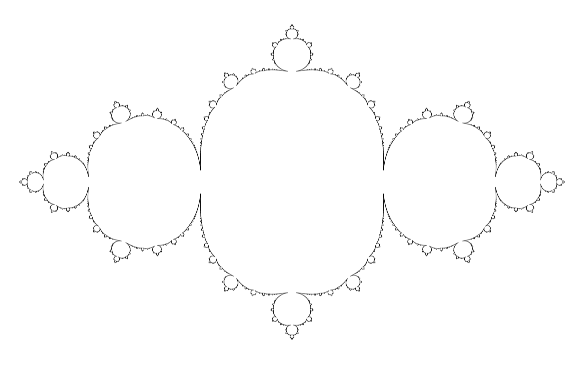

In [ ]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_julia_set_from_escape_times(escape_times, max_iter=modified_max_iter, thickness=julia_thickness, title="", show_axis=False)

In [ ]:
plotter.save_figure(fig, "../../figures/z_squared_minus_z_julia_set.pdf")

Saved figure to: ../../figures/z_squared_minus_z_julia_set.pdf


In [16]:
center = 0.5
max_distance_to_center = 1.55

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center+0.6
ymax = center.imag+max_distance_to_center-0.6

In [ ]:
escape_times = generate_escape_time_fractal_jitted_Rz2mz(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

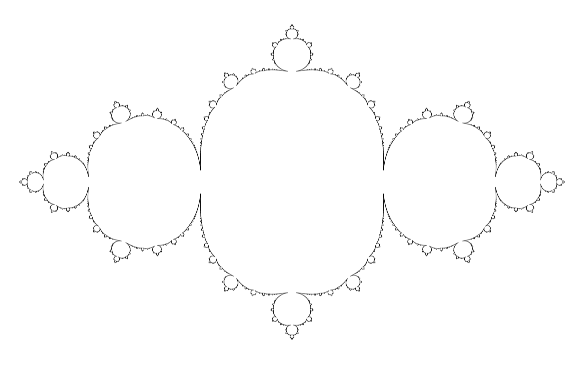

In [19]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_julia_set_from_escape_times(escape_times, max_iter=modified_max_iter, thickness=julia_thickness, title="", show_axis=False)

In [20]:
plotter.save_figure(fig, "../../figures/z_squared_minus_z_julia_set-thin.pdf")

Saved figure to: ../../figures/z_squared_minus_z_julia_set-thin.pdf
